# Classifieur de phrases parallèles — Régression logistique

Ce notebook entraîne un modèle de régression logistique afin d'identifier automatiquement des paires de phrases **parallèles** ou **semi-parallèles** entre le français et les langues régionales de France (alsacien, corse, occitan).

Il s'appuie sur le fichier `similarity_dataset.csv` produit par le notebook précédent, qui contient pour chaque paire :
- un score de similarité sémantique SBERT,
- un score de longueur,
- des indices de Jaccard sur les n-grammes de caractères (bigrammes, trigrammes, quadrigrammes),
- un indice de Jaccard phonétique (Metaphone),
- une étiquette de classe : `parallel`, `semi-parallel`, ou `non-parallel`.

**Pipeline :**
1. Chargement et exploration des données
2. Préparation des variables d'apprentissage
3. Entraînement du modèle (binaire et multiclasse)
4. Évaluation et analyse des résultats
5. Sauvegarde du modèle
6. Fonction d'inférence sur de nouvelles paires



---


## Imports et configuration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import unicodedata
import string
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.pipeline import Pipeline

# -------------------------------------------------------
# Configuration
# -------------------------------------------------------
DATASET_PATH   = "similarity_dataset.csv"
MODEL_BIN_PATH = "logreg_binary.joblib"       # modèle binaire (parallèle vs non-parallèle)
MODEL_MC_PATH  = "logreg_multiclass.joblib"   # modèle multiclasse (3 classes)
SCALER_PATH    = "scaler.joblib"
RANDOM_STATE   = 42
TEST_SIZE      = 0.2

FEATURE_COLS = [
    "sbert_score",
    "length_score",
    "jaccard_bigrams",
    "jaccard_trigrams",
    "jaccard_quadrigrams",
    "phonetic_jaccard",
]

Imports OK — configuration chargée.




---


## Chargement et exploration des données

In [ ]:
df = pd.read_csv(DATASET_PATH, encoding="utf-8-sig")
df.head(3)

Dimensions : 3435 paires × 13 colonnes


,fr_sentence,lr_sentence,language_pair,class,binary_class,sbert_score,length_score,jaccard_bigrams,jaccard_trigrams,jaccard_quadrigrams,phonetic_jaccard,corpus,language
0,L'enseignement élémentaire est obligatoire.,"• Cunsigliu di l’Europa, Cunvenzione europea d...",parcolab_universal_tr__fr-gsw,non-parallel,0,0.249891,0.950617,0.124183,0.021605,0.007282,0.000,parcolab_universal_tr_,gsw
1,"Alors, la bise s'est mise à souffler de toute ...","A quau moment, la bisa se metèt a bofar, tant ...",LIMSI_fr-oc_noc_sannat,parallel,1,0.698508,0.051282,0.445455,0.228571,0.130597,0.225,LIMSI_fr-oc_noc,sannat
2,1.,1.,parcolab_universal_tr__fr-co,semi-parallel,1,1.000000,0.000000,0.000000,0.000000,0.000000,0.000,parcolab_universal_tr_,co


In [ ]:
print("=== Distribution des classes ===")
print(df["class"].value_counts().to_string())

print("\n=== Distribution par langue ===")
# Regroupe les variétés dialectales en 3 grandes langues régionales
regional_map = {
    "co":  "Corse",
    "gsw": "Alsacien",
    "oc":  "Occitan",
}

def map_language(lang):
    if lang in regional_map:
        return regional_map[lang]
    # Les variétés LIMSI sont des localités occitanes
    return "Occitan (dialecte)"

df["langue_groupe"] = df["language"].apply(map_language)
print(df["langue_groupe"].value_counts().to_string())

=== Distribution des classes ===
class
non-parallel     1145
parallel         1145
semi-parallel    1145

=== Distribution par langue ===
langue_groupe
Corse                 1099
Occitan (dialecte)     936
Alsacien               703
Occitan                697


In [ ]:
# Descriptive statistics for learning variables by class
df.groupby("class")[FEATURE_COLS].mean().round(4)

,sbert_score,length_score,jaccard_bigrams,jaccard_trigrams,jaccard_quadrigrams,phonetic_jaccard
class,,,,,,
non-parallel,0.1978,0.5976,0.1525,0.0353,0.0099,0.0335
parallel,0.6165,0.0790,0.4211,0.1868,0.1199,0.2184
semi-parallel,0.4594,0.5617,0.2499,0.0911,0.0584,0.1495


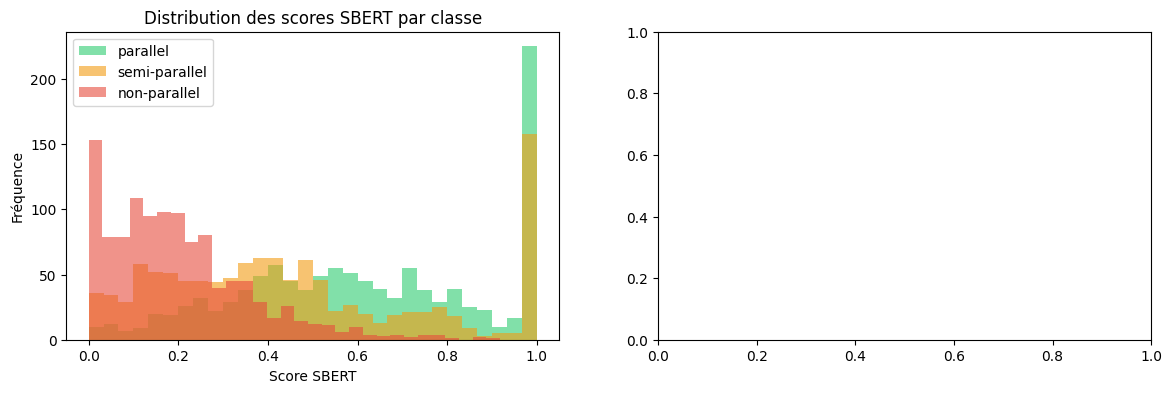

In [ ]:
# SBERT score by class
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = {"parallel": "#2ecc71", "semi-parallel": "#f39c12", "non-parallel": "#e74c3c"}

# Histograms
for cls, color in colors.items():
    subset = df[df["class"] == cls]["sbert_score"]
    axes[0].hist(subset, bins=30, alpha=0.6, color=color, label=cls)
axes[0].set_title("Distribution des scores SBERT par classe")
axes[0].set_xlabel("Score SBERT")
axes[0].set_ylabel("Fréquence")
axes[0].legend()

In [ ]:
# Boxplots
df.boxplot(column="sbert_score", by="class", ax=axes[1],
           color=dict(boxes="blue", medians="red", whiskers="gray", caps="gray"))
axes[1].set_title("Boxplot SBERT par classe")
axes[1].set_xlabel("Classe")
axes[1].set_ylabel("Score SBERT")
plt.suptitle("")
plt.tight_layout()
plt.savefig("sbert_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : sbert_distribution.png")

<Figure size 640x480 with 0 Axes>

Figure sauvegardée : sbert_distribution.png


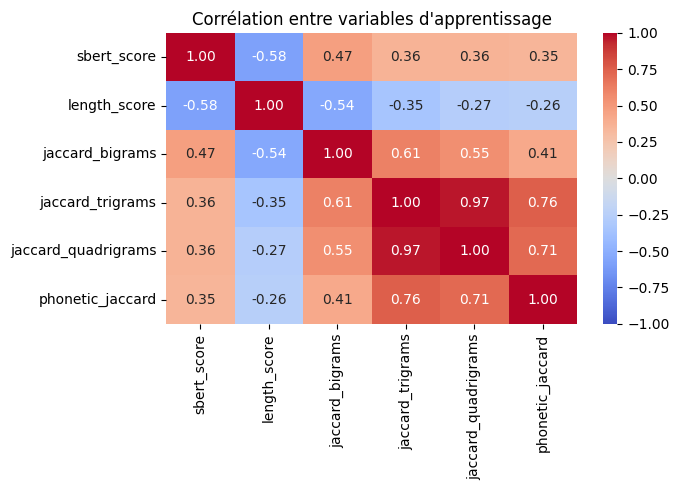

In [ ]:
# Correlation matrix of variables
corr = df[FEATURE_COLS].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, vmin=-1, vmax=1)
ax.set_title("Corrélation entre variables d'apprentissage")
plt.tight_layout()
plt.savefig("feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()



---


## Préparation des données

In [ ]:
X = df[FEATURE_COLS].values

# --- Binary target (1 for parallel and 0 for non-parallel) ---
y_bin = df["binary_class"].values

# --- Multiclass target ---
le = LabelEncoder()
y_mc = le.fit_transform(df["class"])          # 0=non-parallel, 1=parallel, 2=semi-parallel

# --- Train / Test ---
X_train, X_test, y_bin_train, y_bin_test, y_mc_train, y_mc_test = train_test_split(
    X, y_bin, y_mc,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_mc
)

# --- Normalisation ---
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
joblib.dump(scaler, SCALER_PATH)

print(f"\nEntraînement : {X_train_sc.shape[0]} paires")
print(f"Test         : {X_test_sc.shape[0]} paires")

Encodage des classes : {'non-parallel': np.int64(0), 'parallel': np.int64(1), 'semi-parallel': np.int64(2)}

Entraînement : 2748 paires
Test         : 687 paires




---


## Entraînement

### Modèle binaire (parallèle/semi-parallèle vs non-parallèle)

In [ ]:
logreg_bin = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    solver="lbfgs",
)
logreg_bin.fit(X_train_sc, y_bin_train)
joblib.dump(logreg_bin, MODEL_BIN_PATH)
print(f"Modèle binaire sauvegardé : {MODEL_BIN_PATH}")

# 5-fold cross-validation
cv_scores = cross_val_score(logreg_bin, X_train_sc, y_bin_train, cv=5, scoring="f1")
print(f"F1 CV 5-fold (entraînement) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Modèle binaire sauvegardé : logreg_binary.joblib
F1 CV 5-fold (entraînement) : 0.8353 ± 0.0113




---


### Modèle multiclasse (parallel / semi-parallel / non-parallel)

In [ ]:
logreg_mc = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    multi_class="multinomial",
    random_state=RANDOM_STATE,
    solver="lbfgs",
)
logreg_mc.fit(X_train_sc, y_mc_train)
joblib.dump(logreg_mc, MODEL_MC_PATH)
print(f"Modèle multiclasse sauvegardé : {MODEL_MC_PATH}")

cv_mc = cross_val_score(logreg_mc, X_train_sc, y_mc_train, cv=5, scoring="f1_macro")
print(f"F1-macro CV 5-fold (entraînement) : {cv_mc.mean():.4f} ± {cv_mc.std():.4f}")

Modèle multiclasse sauvegardé : logreg_multiclass.joblib
F1-macro CV 5-fold (entraînement) : 0.7312 ± 0.0139




---


## Évaluation

### Modèle binaire

=== Rapport de classification (binaire) ===
                          precision    recall  f1-score   support

           non-parallèle       0.62      0.90      0.73       229
parallèle/semi-parallèle       0.93      0.73      0.82       458

                accuracy                           0.78       687
               macro avg       0.78      0.81      0.78       687
            weighted avg       0.83      0.78      0.79       687



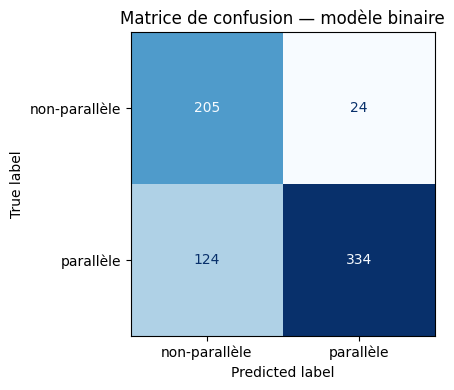

In [ ]:
y_bin_pred  = logreg_bin.predict(X_test_sc)
y_bin_proba = logreg_bin.predict_proba(X_test_sc)[:, 1]

print("=== Rapport de classification (binaire) ===")
print(classification_report(y_bin_test, y_bin_pred,
                             target_names=["non-parallèle", "parallèle/semi-parallèle"]))

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_bin_test, y_bin_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["non-parallèle", "parallèle"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Matrice de confusion — modèle binaire")
plt.tight_layout()
plt.savefig("confusion_binary.png", dpi=150, bbox_inches="tight")
plt.show()

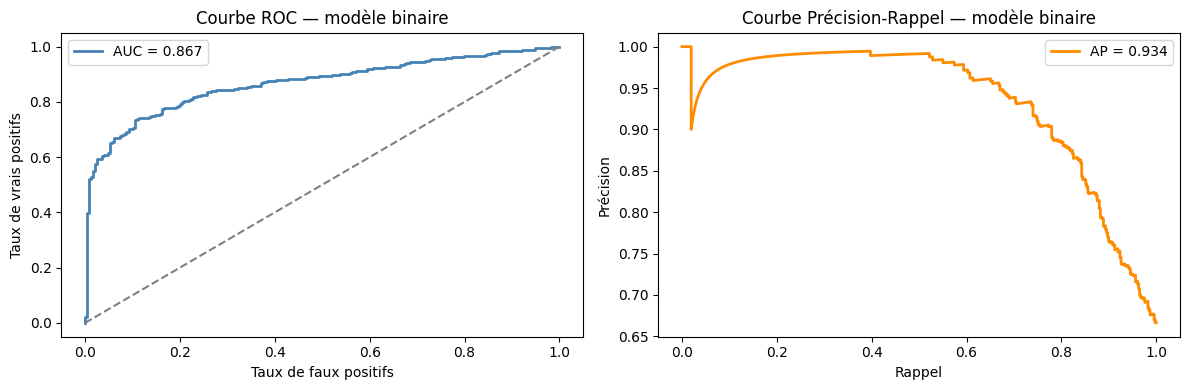

AUC-ROC : 0.8669 | Average Precision : 0.9338


In [ ]:
# ROC curve
fpr, tpr, _ = roc_curve(y_bin_test, y_bin_proba)
auc_score   = roc_auc_score(y_bin_test, y_bin_proba)

# Precision-recall curve
prec, rec, _ = precision_recall_curve(y_bin_test, y_bin_proba)
ap_score     = average_precision_score(y_bin_test, y_bin_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {auc_score:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("Taux de faux positifs")
axes[0].set_ylabel("Taux de vrais positifs")
axes[0].set_title("Courbe ROC — modèle binaire")
axes[0].legend()

axes[1].plot(rec, prec, color="darkorange", lw=2, label=f"AP = {ap_score:.3f}")
axes[1].set_xlabel("Rappel")
axes[1].set_ylabel("Précision")
axes[1].set_title("Courbe Précision-Rappel — modèle binaire")
axes[1].legend()

plt.tight_layout()
plt.savefig("roc_pr_binary.png", dpi=150, bbox_inches="tight")
plt.show()



---


### Modèle multiclasse

=== Rapport de classification (multiclasse) ===
               precision    recall  f1-score   support

 non-parallel       0.67      0.78      0.72       229
     parallel       0.77      0.91      0.83       229
semi-parallel       0.77      0.50      0.60       229

     accuracy                           0.73       687
    macro avg       0.73      0.73      0.72       687
 weighted avg       0.73      0.73      0.72       687



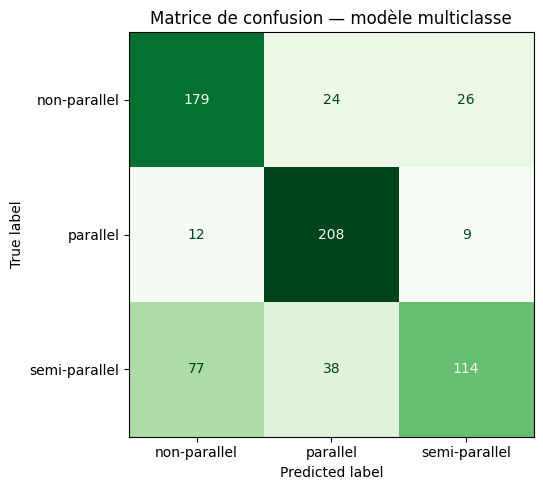

In [ ]:
y_mc_pred = logreg_mc.predict(X_test_sc)

print("=== Rapport de classification (multiclasse) ===")
print(classification_report(y_mc_test, y_mc_pred, target_names=le.classes_))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm_mc = confusion_matrix(y_mc_test, y_mc_pred)
disp_mc = ConfusionMatrixDisplay(cm_mc, display_labels=le.classes_)
disp_mc.plot(ax=ax, colorbar=False, cmap="Greens")
ax.set_title("Matrice de confusion — modèle multiclasse")
plt.tight_layout()
plt.savefig("confusion_multiclass.png", dpi=150, bbox_inches="tight")
plt.show()



---


### Importance des variables

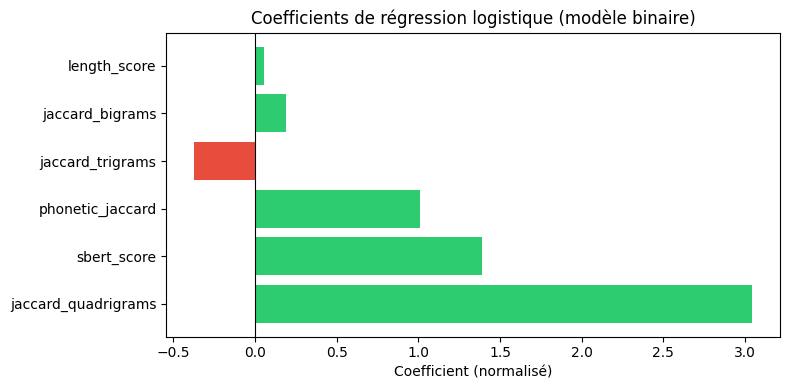

           variable  coefficient
jaccard_quadrigrams     3.043019
        sbert_score     1.390355
   phonetic_jaccard     1.008419
   jaccard_trigrams    -0.372198
    jaccard_bigrams     0.192637
       length_score     0.056683


In [ ]:
# Binary model coefficients
coef_df = pd.DataFrame({
    "variable":   FEATURE_COLS,
    "coefficient": logreg_bin.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors_bar = ["#2ecc71" if c > 0 else "#e74c3c" for c in coef_df["coefficient"]]
ax.barh(coef_df["variable"], coef_df["coefficient"], color=colors_bar)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Coefficients de régression logistique (modèle binaire)")
ax.set_xlabel("Coefficient (normalisé)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print(coef_df.to_string(index=False))



---


### Performances par langue régionale

In [ ]:
from sklearn.metrics import f1_score, accuracy_score

# Get indexes from the test dataset
idx_test = df.index[len(X_train):len(X_train) + len(X_test)]

# Builds an annotated test DataFrame
_, df_test_raw = train_test_split(
    df, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_mc
)
df_test_raw = df_test_raw.copy()
df_test_raw["pred_bin"]  = y_bin_pred
df_test_raw["true_bin"]  = y_bin_test
df_test_raw["pred_class"] = le.inverse_transform(y_mc_pred)

results_by_lang = []
for lang in ["co", "gsw", "oc"]:
    mask = df_test_raw["language"] == lang
    if mask.sum() == 0:
        continue
    sub = df_test_raw[mask]
    f1  = f1_score(sub["true_bin"], sub["pred_bin"], zero_division=0)
    acc = accuracy_score(sub["true_bin"], sub["pred_bin"])
    results_by_lang.append({"Langue": lang, "N test": len(sub), "Accuracy": round(acc, 4), "F1": round(f1, 4)})

lang_df = pd.DataFrame(results_by_lang)
print("=== Performances par langue régionale (modèle binaire) ===")
print(lang_df.to_string(index=False))

=== Performances par langue régionale (modèle binaire) ===
Langue  N test  Accuracy     F1
    co     233    0.8197 0.8489
   gsw     127    0.6299 0.6569
    oc     143    0.9301 0.9462




---


## Sauvegarde et résumé

In [ ]:
print("Fichiers sauvegardés :")
for f in [MODEL_BIN_PATH, MODEL_MC_PATH, SCALER_PATH]:
    print(f"\t+ {f}")

print("\nFigures sauvegardées :")
for f in ["sbert_distribution.png", "feature_correlation.png",
          "confusion_binary.png", "roc_pr_binary.png",
          "confusion_multiclass.png", "feature_importance.png"]:
    print(f"\t+ {f}")

Fichiers sauvegardés :
  ✔ logreg_binary.joblib
  ✔ logreg_multiclass.joblib
  ✔ scaler.joblib

Figures sauvegardées :
  ✔ sbert_distribution.png
  ✔ feature_correlation.png
  ✔ confusion_binary.png
  ✔ roc_pr_binary.png
  ✔ confusion_multiclass.png
  ✔ feature_importance.png




---


## Inférence sur de nouvelles paires

Cette section montre comment utiliser le modèle entraîné pour prédire si une nouvelle paire de phrases est parallèle, semi-parallèle ou non-parallèle.

Les fonctions de calcul des variables sont reprises du notebook de constitution du dataset.

In [ ]:
try:
    import jellyfish
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "jellyfish", "-q"])
    import jellyfish

try:
    from sentence_transformers import SentenceTransformer
    from sklearn.metrics.pairwise import cosine_similarity as cos_sim
    _sbert_available = True
except ImportError:
    _sbert_available = False
    print("sentence-transformers non disponible — le score SBERT sera mis à 0.")

# -------------------------------------------------------
# Variable computing functions
# -------------------------------------------------------

def normalize(text):
    text = text.lower()
    text = unicodedata.normalize("NFD", text)
    text = "".join(c for c in text if unicodedata.category(c) != "Mn")
    return text.translate(str.maketrans("", "", string.punctuation)).strip()

def length_score(s1, s2):
    n1, n2  = len(s1.split()), len(s2.split())
    max_len = max(n1, n2)
    return 0.0 if max_len == 0 else abs(n1 - n2) / max_len

def char_ngrams(text, n):
    t = normalize(text)
    return set(t[i:i+n] for i in range(len(t) - n + 1))

def jaccard_index(a, b):
    if not a and not b:
        return 0.0
    return len(a & b) / len(a | b)

def jaccard_ngrams(s1, s2, n):
    return jaccard_index(char_ngrams(s1, n), char_ngrams(s2, n))

def metaphone_codes(text):
    codes = set()
    for word in normalize(text).split():
        try:
            code = jellyfish.metaphone(word)
            if code:
                codes.add(code)
        except Exception:
            pass
    return codes

def phonetic_jaccard(s1, s2):
    return jaccard_index(metaphone_codes(s1), metaphone_codes(s2))

# Loading SBERT model (once)
if _sbert_available:
    _sbert_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

def compute_features(fr_sentence: str, lr_sentence: str) -> np.ndarray:
    """
    Computes the variables vector for a sentence pair.
    """
    if _sbert_available:
        emb1 = _sbert_model.encode([fr_sentence], convert_to_numpy=True)
        emb2 = _sbert_model.encode([lr_sentence], convert_to_numpy=True)
        sbert = float(max(0.0, cos_sim(emb1, emb2)[0][0]))
    else:
        sbert = 0.0

    return np.array([[
        sbert,
        length_score(fr_sentence, lr_sentence),
        jaccard_ngrams(fr_sentence, lr_sentence, 2),
        jaccard_ngrams(fr_sentence, lr_sentence, 3),
        jaccard_ngrams(fr_sentence, lr_sentence, 4),
        phonetic_jaccard(fr_sentence, lr_sentence),
    ]])


def predict_pair(fr_sentence: str, lr_sentence: str, mode: str = "binary") -> dict:
    """
    Predicts whether a sentence pair is parallel, semi-parallel or non-parallel.
    """
    # Loading models and scaler
    scaler_     = joblib.load(SCALER_PATH)
    model_bin_  = joblib.load(MODEL_BIN_PATH)
    model_mc_   = joblib.load(MODEL_MC_PATH)

    feats = compute_features(fr_sentence, lr_sentence)
    feats_sc = scaler_.transform(feats)

    if mode == "binary":
        pred  = model_bin_.predict(feats_sc)[0]
        proba = model_bin_.predict_proba(feats_sc)[0]
        label = "parallèle / semi-parallèle" if pred == 1 else "non-parallèle"
        conf  = proba[pred]
    else:
        pred  = model_mc_.predict(feats_sc)[0]
        proba = model_mc_.predict_proba(feats_sc)[0]
        label = le.inverse_transform([pred])[0]
        conf  = proba[pred]

    return {
        "prediction":  label,
        "confidence":  round(float(conf), 4),
        "features":    dict(zip(FEATURE_COLS, feats[0].tolist())),
    }

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [ ]:
# -------------------------------------------------------
# Inference exemple
# -------------------------------------------------------
test_pairs = [
    (
        "La bise et le soleil se disputaient, chacun assurant qu'il était le plus fort.",
        "La bisa e lo solelh se disputavan, cascun assegurant qu'èra lo mai fòrt.",   # occitan
        "Parallèle attendue"
    ),
    (
        "La bise et le soleil se disputaient, chacun assurant qu'il était le plus fort.",
        "La bisa e lo solelh se disputavan.",   # semi-parallel
        "Semi-parallèle attendue"
    ),
    (
        "Le gouvernement a annoncé de nouvelles mesures économiques.",
        "U ghjornu hè bellu è u mare hè calmu.",   # corsican, non parallel
        "Non-parallèle attendue"
    ),
    (
        "L'enseignement élémentaire est obligatoire.",
        "D'Grundschulbildig isch pflichtisch.",   # alsacian
        "Parallèle attendue"
    ),
]

print("=" * 70)
for fr, lr, expected in test_pairs:
    result_bin = predict_pair(fr, lr, mode="binary")
    result_mc  = predict_pair(fr, lr, mode="multiclass")
    print(f"[{expected}]")
    print(f"  FR : {fr[:70]}")
    print(f"  LR : {lr[:70]}")
    print(f"  Binaire     → {result_bin['prediction']}  (confiance : {result_bin['confidence']:.2%})")
    print(f"  Multiclasse → {result_mc['prediction']}  (confiance : {result_mc['confidence']:.2%})")
    print("-" * 70)